# Crisis Connect — Phase 2: CNN Image Classifier (ResNet-50)
**CSC-233 Artificial Intelligence Lab | Spring 2026**
**Component owner: Maleeha Fatima**

### Classes: earthquake | flood | fire | traffic_incident

**What this notebook does:**
1. Loads your split dataset from Drive
2. Applies data augmentation on training set
3. Loads pretrained ResNet-50 and replaces the final layer for 4-class output
4. Trains the model with early stopping
5. Evaluates on test set — accuracy, precision, recall, F1
6. Plots confusion matrix and training curves
7. Saves the trained model to Drive

**Before running:** Make sure GPU is enabled.
Runtime → Change runtime type → T4 GPU → Save

Dataset path used: `/content/drive/MyDrive/crisis connect_split`

## Cell 1 — Install and import

In [13]:
!pip install torchvision scikit-learn matplotlib seaborn -q

import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cpu':
    print('WARNING: GPU not detected. Go to Runtime > Change runtime type > T4 GPU')

Using device: cuda


## Cell 2 — Mount Drive and set paths

In [14]:
from google.colab import drive
drive.mount('/content/drive')

import os

SPLIT_DIR  = '/content/drive/MyDrive/crisis connect_split'
MODEL_DIR  = '/content/drive/MyDrive/crisis connect_model'
CLASSES    = ['earthquake', 'flood', 'fire', 'traffic_incident']
NUM_CLASSES = len(CLASSES)

os.makedirs(MODEL_DIR, exist_ok=True)

print('Dataset path:', SPLIT_DIR)
print('Model will be saved to:', MODEL_DIR)
print()
print('Verifying split folders...')
for split in ['train', 'val', 'test']:
    print(f'  {split}/')
    for cls in CLASSES:
        path = os.path.join(SPLIT_DIR, split, cls)
        n = len(os.listdir(path)) if os.path.exists(path) else 0
        print(f'    {cls:<22} {n} images')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset path: /content/drive/MyDrive/crisis connect_split
Model will be saved to: /content/drive/MyDrive/crisis connect_model

Verifying split folders...
  train/
    earthquake             397 images
    flood                  482 images
    fire                   438 images
    traffic_incident       339 images
  val/
    earthquake             104 images
    flood                  135 images
    fire                   124 images
    traffic_incident       72 images
  test/
    earthquake             122 images
    flood                  130 images
    fire                   120 images
    traffic_incident       74 images


In [15]:
import os

SPLIT_DIR = '/content/drive/MyDrive/crisis connect_split'

print("What is inside crisis connect_split:")
for item in os.listdir(SPLIT_DIR):
    print(f"  [{item}]")

print()
print("What is inside train/:")
train_path = os.path.join(SPLIT_DIR, 'train')
for item in os.listdir(train_path):
    print(f"  [{item}]")


What is inside crisis connect_split:
  [train]
  [val]
  [test]

What is inside train/:
  [earthquake]
  [flood]
  [fire]
  [traffic_incident]


In [16]:
import os, shutil

SPLIT_DIR = '/content/drive/MyDrive/crisis connect_split'

# Keep only these exact names, delete everything else
KEEP = ['earthquake', 'flood', 'fire', 'traffic_incident']

for split in ['train', 'val', 'test']:
    split_path = os.path.join(SPLIT_DIR, split)
    for folder in os.listdir(split_path):
        folder_path = os.path.join(split_path, folder)
        if folder not in KEEP:
            shutil.rmtree(folder_path)
            print(f'Deleted: {split}/{folder}')

print()
print('Remaining folders:')
for split in ['train', 'val', 'test']:
    items = os.listdir(os.path.join(SPLIT_DIR, split))
    print(f'  {split}/ → {items}')


Remaining folders:
  train/ → ['earthquake', 'flood', 'fire', 'traffic_incident']
  val/ → ['earthquake', 'flood', 'fire', 'traffic_incident']
  test/ → ['earthquake', 'flood', 'fire', 'traffic_incident']


## Cell 3 — Data transforms and loaders

In [17]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ImageNet mean and std — required for pretrained ResNet-50
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training: augmentation to help model generalise
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Val and test: no augmentation, just resize and normalize
eval_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_dataset = datasets.ImageFolder(os.path.join(SPLIT_DIR, 'train'), transform=train_transforms)
val_dataset   = datasets.ImageFolder(os.path.join(SPLIT_DIR, 'val'),   transform=eval_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(SPLIT_DIR, 'test'),  transform=eval_transforms)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples : {len(train_dataset)}')
print(f'Val samples   : {len(val_dataset)}')
print(f'Test samples  : {len(test_dataset)}')
print(f'Batch size    : {BATCH_SIZE}')
print(f'Class mapping : {train_dataset.class_to_idx}')

Train samples : 1656
Val samples   : 435
Test samples  : 446
Batch size    : 32
Class mapping : {'earthquake': 0, 'fire': 1, 'flood': 2, 'traffic_incident': 3}


## Cell 4 — Load ResNet-50 with transfer learning

In [18]:
from torchvision import models
import torch.nn as nn

# Load pretrained ResNet-50 (trained on ImageNet)
model = models.resnet50(pretrained=True)

# Freeze all layers — we only train the final classifier head
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
# ResNet-50 default: fc = Linear(2048, 1000)
# We replace with: fc = Linear(2048, 4) for our 4 classes
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(device)

# Count trainable parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}  (final layer only)')
print(f'Frozen parameters    : {total_params - trainable_params:,}')
print()
print('ResNet-50 loaded with pretrained ImageNet weights.')
print('Only the final classification head will be trained.')

Total parameters     : 23,516,228
Trainable parameters : 8,196  (final layer only)
Frozen parameters    : 23,508,032

ResNet-50 loaded with pretrained ImageNet weights.
Only the final classification head will be trained.


## Cell 5 — Define loss, optimizer, scheduler

In [19]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# Only pass trainable params to optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

# Reduce learning rate by 0.5 every 3 epochs
scheduler = StepLR(optimizer, step_size=3, gamma=0.5)

NUM_EPOCHS    = 15
PATIENCE      = 4   # early stopping: stop if val loss doesn't improve for 4 epochs

print(f'Loss function : CrossEntropyLoss')
print(f'Optimizer     : Adam  (lr=0.001)')
print(f'Scheduler     : StepLR  (step=3, gamma=0.5)')
print(f'Max epochs    : {NUM_EPOCHS}')
print(f'Early stopping: patience = {PATIENCE} epochs')

Loss function : CrossEntropyLoss
Optimizer     : Adam  (lr=0.001)
Scheduler     : StepLR  (step=3, gamma=0.5)
Max epochs    : 15
Early stopping: patience = 4 epochs


## Cell 6 — Training loop with early stopping

In [20]:
import copy, time

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_loss  = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
patience_count = 0

print('Starting training...')
print('='*70)

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            loader = train_loader
        else:
            model.eval()
            loader = val_loader

        running_loss    = 0.0
        running_correct = 0

        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
                preds   = outputs.argmax(dim=1)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss    += loss.item() * inputs.size(0)
            running_correct += (preds == labels).sum().item()

        epoch_loss = running_loss    / len(loader.dataset)
        epoch_acc  = running_correct / len(loader.dataset)

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc)

    scheduler.step()

    epoch_time = time.time() - epoch_start
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS}  "
          f"train_loss: {history['train_loss'][-1]:.4f}  "
          f"train_acc: {history['train_acc'][-1]:.4f}  "
          f"val_loss: {history['val_loss'][-1]:.4f}  "
          f"val_acc: {history['val_acc'][-1]:.4f}  "
          f"({epoch_time:.0f}s)")

    # Early stopping
    if history['val_loss'][-1] < best_val_loss:
        best_val_loss  = history['val_loss'][-1]
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}. Best val_loss: {best_val_loss:.4f}')
            break

# Load best weights
model.load_state_dict(best_model_wts)
print('='*70)
print('Training complete. Best model weights loaded.')

Starting training...
Epoch 01/15  train_loss: 0.9557  train_acc: 0.6316  val_loss: 0.4218  val_acc: 0.9172  (17s)
Epoch 02/15  train_loss: 0.6064  train_acc: 0.7826  val_loss: 0.3485  val_acc: 0.8920  (15s)
Epoch 03/15  train_loss: 0.5057  train_acc: 0.8116  val_loss: 0.2811  val_acc: 0.9126  (16s)
Epoch 04/15  train_loss: 0.4570  train_acc: 0.8448  val_loss: 0.2668  val_acc: 0.9103  (16s)
Epoch 05/15  train_loss: 0.4360  train_acc: 0.8357  val_loss: 0.2355  val_acc: 0.9356  (15s)
Epoch 06/15  train_loss: 0.4508  train_acc: 0.8388  val_loss: 0.2719  val_acc: 0.9195  (15s)
Epoch 07/15  train_loss: 0.4118  train_acc: 0.8551  val_loss: 0.2196  val_acc: 0.9287  (15s)
Epoch 08/15  train_loss: 0.3808  train_acc: 0.8678  val_loss: 0.2339  val_acc: 0.9310  (15s)
Epoch 09/15  train_loss: 0.4074  train_acc: 0.8527  val_loss: 0.2152  val_acc: 0.9287  (21s)
Epoch 10/15  train_loss: 0.4213  train_acc: 0.8551  val_loss: 0.2180  val_acc: 0.9264  (15s)
Epoch 11/15  train_loss: 0.4008  train_acc: 0.853

## Cell 7 — Plot training curves

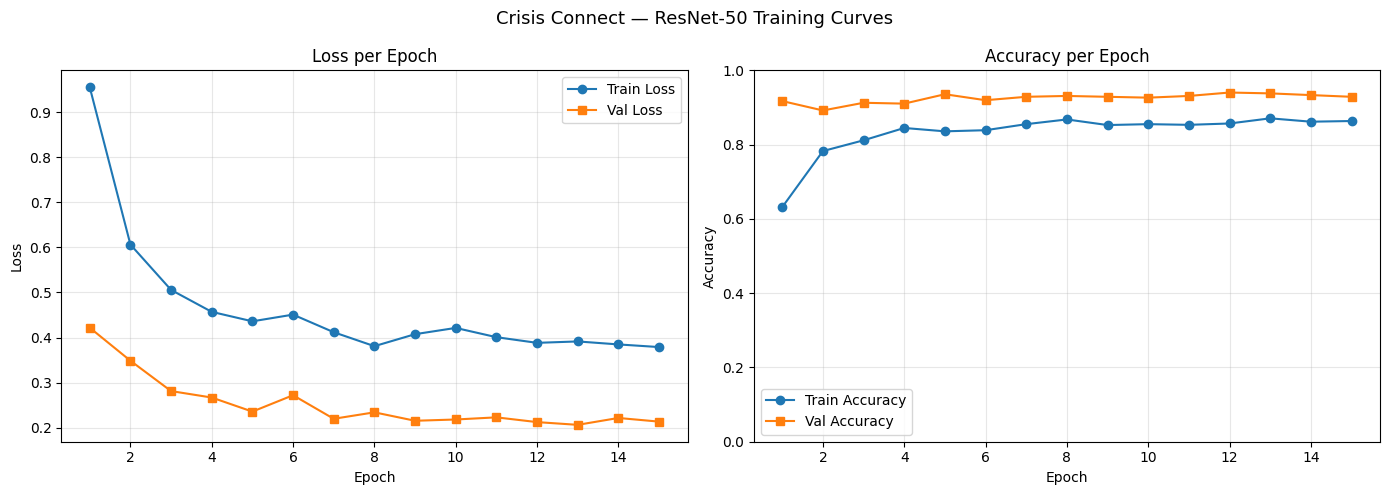

Training curves saved to Drive: /content/drive/MyDrive/crisis connect_model/training_curves.png


In [21]:
import matplotlib.pyplot as plt

epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Crisis Connect — ResNet-50 Training Curves', fontsize=13)

# Loss
axes[0].plot(x, history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(x, history['val_loss'],   label='Val Loss',   marker='s')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(x, history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(x, history['val_acc'],   label='Val Accuracy',   marker='s')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
curve_path = os.path.join(MODEL_DIR, 'training_curves.png')
plt.savefig(curve_path, dpi=100)
plt.show()
print(f'Training curves saved to Drive: {curve_path}')

## Cell 8 — Evaluate on test set

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Overall accuracy
test_acc = (all_preds == all_labels).mean()
print(f'Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')
print()

# Per-class report
print('Classification Report:')
print('='*60)
print(classification_report(
    all_labels, all_preds,
    target_names=CLASSES,
    digits=4
))

Test Accuracy: 0.9103  (91.03%)

Classification Report:
                  precision    recall  f1-score   support

      earthquake     0.8926    0.8852    0.8889       122
           flood     0.9820    0.9083    0.9437       120
            fire     0.9457    0.9385    0.9421       130
traffic_incident     0.7882    0.9054    0.8428        74

        accuracy                         0.9103       446
       macro avg     0.9021    0.9094    0.9044       446
    weighted avg     0.9148    0.9103    0.9115       446



## Cell 9 — Confusion matrix

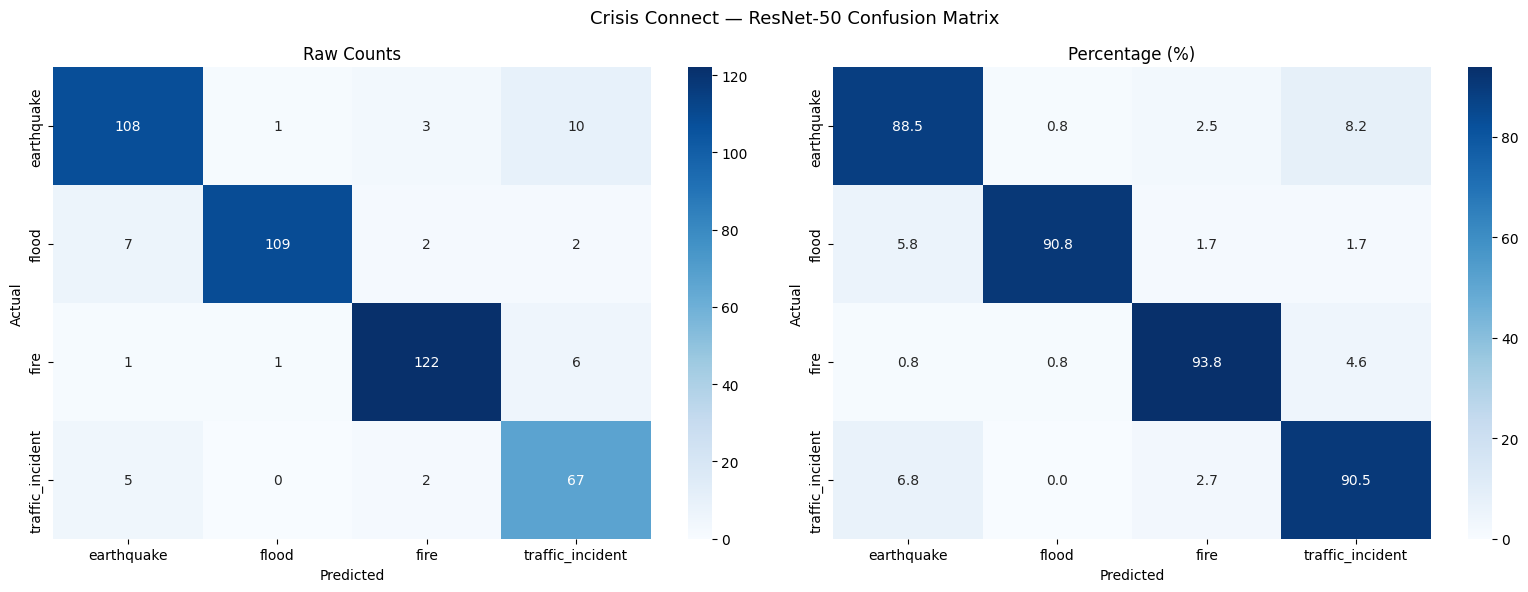

Confusion matrix saved: /content/drive/MyDrive/crisis connect_model/confusion_matrix.png


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

# Normalize to percentages
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Crisis Connect — ResNet-50 Confusion Matrix', fontsize=13)

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Raw Counts')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Percentages
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title('Percentage (%)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
cm_path = os.path.join(MODEL_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=100)
plt.show()
print(f'Confusion matrix saved: {cm_path}')

## Cell 10 — Save model to Drive

In [24]:
import torch, os, json

# Save full model weights
model_path = os.path.join(MODEL_DIR, 'resnet50_crisis_connect.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'class_to_idx':     train_dataset.class_to_idx,
    'classes':          CLASSES,
    'num_classes':      NUM_CLASSES,
    'test_accuracy':    float(test_acc),
    'history':          history
}, model_path)

print(f'Model saved: {model_path}')
print()
print('Contents saved to crisis connect_model/ on Drive:')
for f in os.listdir(MODEL_DIR):
    size_mb = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1024 / 1024
    print(f'  {f:<35} {size_mb:.1f} MB')
print()
print('Hand off to Hudair for Phase 4 (Fusion Layer):')
print(f'  Model path : {model_path}')
print(f'  Classes    : {CLASSES}')
print(f'  Test acc   : {test_acc*100:.2f}%')

Model saved: /content/drive/MyDrive/crisis connect_model/resnet50_crisis_connect.pth

Contents saved to crisis connect_model/ on Drive:
  training_curves.png                 0.1 MB
  confusion_matrix.png                0.1 MB
  resnet50_crisis_connect.pth         90.0 MB

Hand off to Hudair for Phase 4 (Fusion Layer):
  Model path : /content/drive/MyDrive/crisis connect_model/resnet50_crisis_connect.pth
  Classes    : ['earthquake', 'flood', 'fire', 'traffic_incident']
  Test acc   : 91.03%


## Cell 11 — Quick inference test (sanity check)

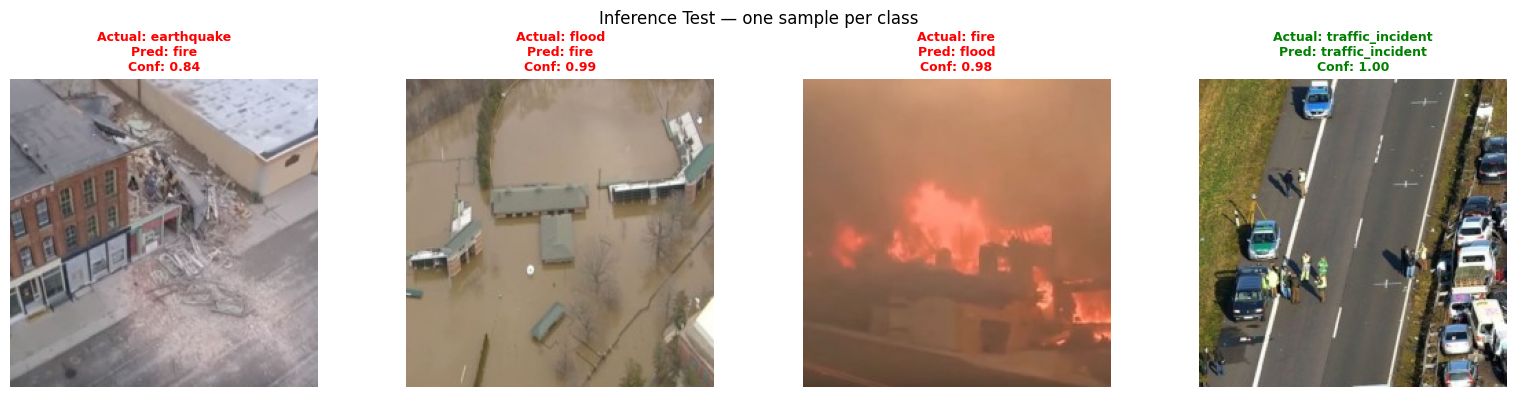

Inference test saved: /content/drive/MyDrive/crisis connect_model/inference_test.png

Phase 2 complete.
Share the crisis connect_model/ folder with Hudair for Phase 4.


In [25]:
from PIL import Image
import torch, os, random
import matplotlib.pyplot as plt

model.eval()

# Pick one random image from each test class and predict
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(NUM_CLASSES * 4, 4))
fig.suptitle('Inference Test — one sample per class', fontsize=12)

for i, cls in enumerate(CLASSES):
    folder = os.path.join(SPLIT_DIR, 'test', cls)
    files  = [f for f in os.listdir(folder) if f.endswith('.jpg')]
    fname  = random.choice(files)
    fpath  = os.path.join(folder, fname)

    img_pil = Image.open(fpath).convert('RGB')
    tensor  = eval_transforms(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1)[0]
        pred_idx = probs.argmax().item()
        pred_cls = CLASSES[pred_idx]
        confidence = probs[pred_idx].item()

    color = 'green' if pred_cls == cls else 'red'
    axes[i].imshow(img_pil)
    axes[i].axis('off')
    axes[i].set_title(
        f'Actual: {cls}\nPred: {pred_cls}\nConf: {confidence:.2f}',
        fontsize=9, color=color, fontweight='bold'
    )

plt.tight_layout()
infer_path = os.path.join(MODEL_DIR, 'inference_test.png')
plt.savefig(infer_path, dpi=100)
plt.show()
print(f'Inference test saved: {infer_path}')
print()
print('Phase 2 complete.')
print('Share the crisis connect_model/ folder with Hudair for Phase 4.')